# LaptopDataSet

In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_curve,roc_auc_score

In [41]:
df = pd.read_csv("C:\\Users\\HP\\Desktop\\DATASCIENCE\\ML day 4\\laptopData.csv")
df

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080
...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.6400
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.7200
1300,Lenovo,Notebook,14,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.1200
1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.9200


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1273 non-null   object 
 1   TypeName          1273 non-null   object 
 2   Inches            1273 non-null   object 
 3   ScreenResolution  1273 non-null   object 
 4   Cpu               1273 non-null   object 
 5   Ram               1273 non-null   object 
 6   Memory            1273 non-null   object 
 7   Gpu               1273 non-null   object 
 8   OpSys             1273 non-null   object 
 9   Weight            1273 non-null   object 
 10  Price             1273 non-null   float64
dtypes: float64(1), object(10)
memory usage: 112.1+ KB


In [43]:
df.describe()

,Price
count,1273.000000
mean,59955.814073
std,37332.251005
min,9270.720000
25%,31914.720000
50%,52161.120000
75%,79333.387200
max,324954.720000


In [44]:
df.isnull().sum()

Company             30
TypeName            30
Inches              30
ScreenResolution    30
Cpu                 30
Ram                 30
Memory              30
Gpu                 30
OpSys               30
Weight              30
Price               30
dtype: int64

In [45]:
df.dropna(how="all",inplace=True)

In [46]:
df.isnull().sum()

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

# Preprocessing

Company	Encode (categorical)	

TypeName	Encode (categorical)	

Inches	Convert to float	

ScreenResolution	Extract features (Touch, IPS, PPI)	

Cpu	Extract CPU brand/type	

Ram	Convert to int (in GB)	

Memory	Extract SSD/HDD/Hybrid values	

Gpu	Extract GPU brand	

OpSys	Encode	

Weight	Convert to float

In [47]:
df['Company'] = df['Company'].str.strip()
company_dummies = pd.get_dummies(df['Company'],prefix='Brand',drop_first=True)
df=pd.concat([df.drop('Company',axis=1),company_dummies],axis=1)

In [48]:
df

,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,...,Brand_LG,Brand_Lenovo,Brand_MSI,Brand_Mediacom,Brand_Microsoft,Brand_Razer,Brand_Samsung,Brand_Toshiba,Brand_Vero,Brand_Xiaomi
0,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,...,False,False,False,False,False,False,False,False,False,False
1,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,...,False,False,False,False,False,False,False,False,False,False
2,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,...,False,False,False,False,False,False,False,False,False,False
3,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,...,False,False,False,False,False,False,False,False,False,False
4,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,2 in 1 Convertible,14,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.6400,...,False,True,False,False,False,False,False,False,False,False
1299,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.7200,...,False,True,False,False,False,False,False,False,False,False
1300,Notebook,14,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.1200,...,False,True,False,False,False,False,False,False,False,False
1301,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.9200,...,False,False,False,False,False,False,False,False,False,False


In [49]:
df['TypeName'].value_counts()

TypeName
Notebook              710
Gaming                203
Ultrabook             191
2 in 1 Convertible    116
Workstation            29
Netbook                24
Name: count, dtype: int64

In [50]:
df=pd.get_dummies(df,columns=["TypeName"],drop_first=False)

In [51]:
df

,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Brand_Apple,...,Brand_Samsung,Brand_Toshiba,Brand_Vero,Brand_Xiaomi,TypeName_2 in 1 Convertible,TypeName_Gaming,TypeName_Netbook,TypeName_Notebook,TypeName_Ultrabook,TypeName_Workstation
0,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,True,...,False,False,False,False,False,False,False,False,True,False
1,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,True,...,False,False,False,False,False,False,False,False,True,False
2,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,False,...,False,False,False,False,False,False,False,True,False,False
3,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,True,...,False,False,False,False,False,False,False,False,True,False
4,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,True,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,14,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.6400,False,...,False,False,False,False,True,False,False,False,False,False
1299,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.7200,False,...,False,False,False,False,True,False,False,False,False,False
1300,14,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.1200,False,...,False,False,False,False,False,False,False,True,False,False
1301,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.9200,False,...,False,False,False,False,False,False,False,True,False,False


In [52]:
df['Inches'].unique()

array(['13.3', '15.6', '15.4', '14', '12', '17.3', '13.5', '12.5', '13',
       '18.4', '13.9', '11.6', '25.6', '35.6', '12.3', '27.3', '24',
       '33.5', '?', '31.6', '17', '15', '14.1', '11.3', '10.1'],
      dtype=object)

In [53]:
df.replace(to_replace='?',value=np.nan,inplace=True)

In [54]:
df['Inches'].unique()

array(['13.3', '15.6', '15.4', '14', '12', '17.3', '13.5', '12.5', '13',
       '18.4', '13.9', '11.6', '25.6', '35.6', '12.3', '27.3', '24',
       '33.5', nan, '31.6', '17', '15', '14.1', '11.3', '10.1'],
      dtype=object)

In [55]:
df["Inches"]=df["Inches"].astype(float)

In [56]:
df.fillna({"Inches":df['Inches'].median()},inplace=True)

In [57]:
df["Inches"].isnull().sum()

np.int64(0)

In [58]:
df['Ram'] = df['Ram'].str.replace('GB', '').astype(int)

In [59]:
df.head()

,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Brand_Apple,...,Brand_Samsung,Brand_Toshiba,Brand_Vero,Brand_Xiaomi,TypeName_2 in 1 Convertible,TypeName_Gaming,TypeName_Netbook,TypeName_Notebook,TypeName_Ultrabook,TypeName_Workstation
0,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,True,...,False,False,False,False,False,False,False,False,True,False
1,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,True,...,False,False,False,False,False,False,False,False,True,False
2,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,False,...,False,False,False,False,False,False,False,True,False,False
3,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,True,...,False,False,False,False,False,False,False,False,True,False
4,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,True,...,False,False,False,False,False,False,False,False,True,False


In [60]:
df['Weight'] = df['Weight'].str.replace('kg', '').astype(float)

In [61]:
df['Weight'].isnull().sum()

np.int64(1)

In [62]:
df.fillna(df['Weight'].median(),inplace=True)

In [63]:
df['Weight'].isnull().sum()

np.int64(0)

In [64]:
df.head()

,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Brand_Apple,...,Brand_Samsung,Brand_Toshiba,Brand_Vero,Brand_Xiaomi,TypeName_2 in 1 Convertible,TypeName_Gaming,TypeName_Netbook,TypeName_Notebook,TypeName_Ultrabook,TypeName_Workstation
0,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,True,...,False,False,False,False,False,False,False,False,True,False
1,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,True,...,False,False,False,False,False,False,False,False,True,False
2,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,False,...,False,False,False,False,False,False,False,True,False,False
3,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,True,...,False,False,False,False,False,False,False,False,True,False
4,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,True,...,False,False,False,False,False,False,False,False,True,False


# Distribution of Target Variable (Price)

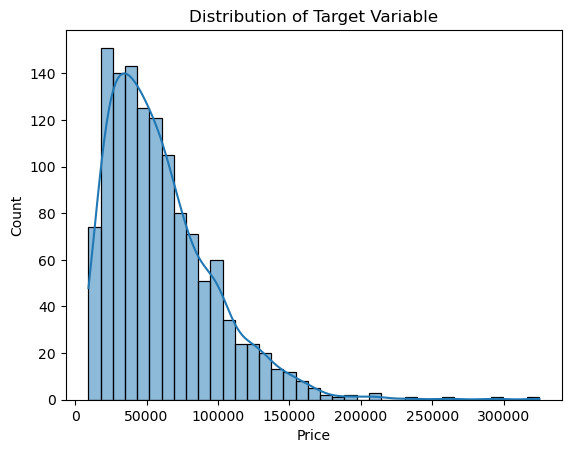

In [65]:
sns.histplot(df['Price'], kde=True)
plt.title("Distribution of Target Variable")
plt.show()

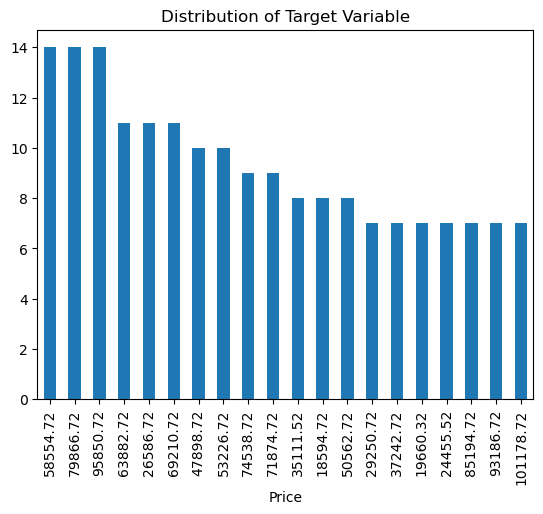

In [66]:
df['Price'].value_counts().head(20).plot(kind = 'bar')
plt.title("Distribution of Target Variable")
plt.show()

<Axes: title={'center': 'Price'}, xlabel='OpSys'>

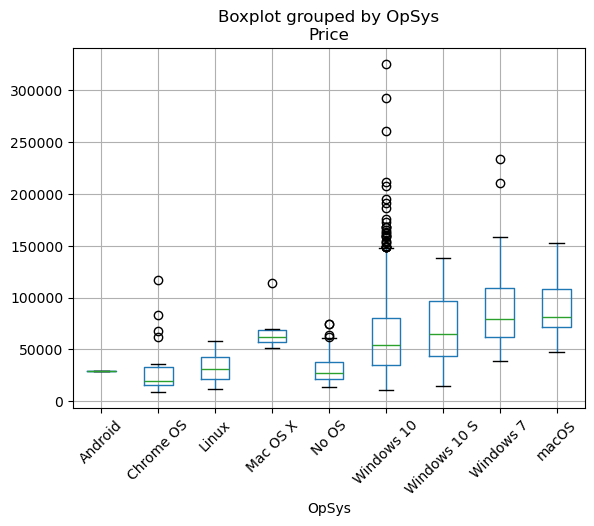

In [67]:
df.boxplot(column='Price', by='OpSys', rot=45)

In [68]:
df.drop(columns=['ScreenResolution'],inplace=True)

In [71]:
df.head()

,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Brand_Apple,Brand_Asus,...,Brand_Samsung,Brand_Toshiba,Brand_Vero,Brand_Xiaomi,TypeName_2 in 1 Convertible,TypeName_Gaming,TypeName_Netbook,TypeName_Notebook,TypeName_Ultrabook,TypeName_Workstation
0,13.3,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,True,False,...,False,False,False,False,False,False,False,False,True,False
1,13.3,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,True,False,...,False,False,False,False,False,False,False,False,True,False
2,15.6,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,False,False,...,False,False,False,False,False,False,False,True,False,False
3,15.4,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,True,False,...,False,False,False,False,False,False,False,False,True,False
4,13.3,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,True,False,...,False,False,False,False,False,False,False,False,True,False


In [72]:
# Create a new column with just the CPU brand
df['Cpu Brand'] = df['Cpu'].apply(lambda x: ' '.join(x.split()[:3]))

In [73]:
df['Cpu Brand'].value_counts()

Cpu Brand
Intel Core i7               515
Intel Core i5               410
Intel Core i3               134
Intel Celeron Dual           79
Intel Pentium Quad           27
Intel Core M                 19
AMD A9-Series 9420           12
AMD A6-Series 9220            8
Intel Celeron Quad            8
AMD A12-Series 9720P          7
Intel Atom x5-Z8350           4
AMD A8-Series 7410            4
AMD A9-Series 9410            3
Intel Atom x5-Z8550           3
Intel Pentium Dual            3
AMD Ryzen 1700                3
Intel Xeon E3-1535M           2
Intel Atom X5-Z8350           2
AMD E-Series E2-9000e         2
AMD A10-Series 9600P          2
AMD A10-Series 9620P          2
AMD A6-Series A6-9220         2
AMD A10-Series A10-9620P      2
Intel Xeon E3-1505M           2
AMD A9-Series A9-9420         2
AMD E-Series 7110             2
AMD E-Series E2-6110          1
Intel Atom x5-Z8300           1
AMD Ryzen 1600                1
AMD FX 9830P                  1
AMD E-Series 6110             

In [74]:
# Drop original Cpu column
df.drop('Cpu', axis=1, inplace=True)

In [75]:
df.head()

,Inches,Ram,Memory,Gpu,OpSys,Weight,Price,Brand_Apple,Brand_Asus,Brand_Chuwi,...,Brand_Toshiba,Brand_Vero,Brand_Xiaomi,TypeName_2 in 1 Convertible,TypeName_Gaming,TypeName_Netbook,TypeName_Notebook,TypeName_Ultrabook,TypeName_Workstation,Cpu Brand
0,13.3,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,True,False,False,...,False,False,False,False,False,False,False,True,False,Intel Core i5
1,13.3,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,True,False,False,...,False,False,False,False,False,False,False,True,False,Intel Core i5
2,15.6,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,False,False,False,...,False,False,False,False,False,False,True,False,False,Intel Core i5
3,15.4,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,True,False,False,...,False,False,False,False,False,False,False,True,False,Intel Core i7
4,13.3,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,True,False,False,...,False,False,False,False,False,False,False,True,False,Intel Core i5


In [76]:
df['Gpu Brand'] = df['Gpu'].apply(lambda x: x.split()[0])
df['Gpu Brand'].value_counts()

Gpu Brand
Intel     703
Nvidia    393
AMD       176
ARM         1
Name: count, dtype: int64

In [77]:
# Drop original Gpu column
df.drop('Gpu', axis=1, inplace=True)

In [78]:
df.head()

,Inches,Ram,Memory,OpSys,Weight,Price,Brand_Apple,Brand_Asus,Brand_Chuwi,Brand_Dell,...,Brand_Vero,Brand_Xiaomi,TypeName_2 in 1 Convertible,TypeName_Gaming,TypeName_Netbook,TypeName_Notebook,TypeName_Ultrabook,TypeName_Workstation,Cpu Brand,Gpu Brand
0,13.3,8,128GB SSD,macOS,1.37,71378.6832,True,False,False,False,...,False,False,False,False,False,False,True,False,Intel Core i5,Intel
1,13.3,8,128GB Flash Storage,macOS,1.34,47895.5232,True,False,False,False,...,False,False,False,False,False,False,True,False,Intel Core i5,Intel
2,15.6,8,256GB SSD,No OS,1.86,30636.0000,False,False,False,False,...,False,False,False,False,False,True,False,False,Intel Core i5,Intel
3,15.4,16,512GB SSD,macOS,1.83,135195.3360,True,False,False,False,...,False,False,False,False,False,False,True,False,Intel Core i7,AMD
4,13.3,8,256GB SSD,macOS,1.37,96095.8080,True,False,False,False,...,False,False,False,False,False,False,True,False,Intel Core i5,Intel


In [79]:
df

,Inches,Ram,Memory,OpSys,Weight,Price,Brand_Apple,Brand_Asus,Brand_Chuwi,Brand_Dell,...,Brand_Vero,Brand_Xiaomi,TypeName_2 in 1 Convertible,TypeName_Gaming,TypeName_Netbook,TypeName_Notebook,TypeName_Ultrabook,TypeName_Workstation,Cpu Brand,Gpu Brand
0,13.3,8,128GB SSD,macOS,1.37,71378.6832,True,False,False,False,...,False,False,False,False,False,False,True,False,Intel Core i5,Intel
1,13.3,8,128GB Flash Storage,macOS,1.34,47895.5232,True,False,False,False,...,False,False,False,False,False,False,True,False,Intel Core i5,Intel
2,15.6,8,256GB SSD,No OS,1.86,30636.0000,False,False,False,False,...,False,False,False,False,False,True,False,False,Intel Core i5,Intel
3,15.4,16,512GB SSD,macOS,1.83,135195.3360,True,False,False,False,...,False,False,False,False,False,False,True,False,Intel Core i7,AMD
4,13.3,8,256GB SSD,macOS,1.37,96095.8080,True,False,False,False,...,False,False,False,False,False,False,True,False,Intel Core i5,Intel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,14.0,4,128GB SSD,Windows 10,1.80,33992.6400,False,False,False,False,...,False,False,True,False,False,False,False,False,Intel Core i7,Intel
1299,13.3,16,512GB SSD,Windows 10,1.30,79866.7200,False,False,False,False,...,False,False,True,False,False,False,False,False,Intel Core i7,Intel
1300,14.0,2,64GB Flash Storage,Windows 10,1.50,12201.1200,False,False,False,False,...,False,False,False,False,False,True,False,False,Intel Celeron Dual,Intel
1301,15.6,6,1TB HDD,Windows 10,2.19,40705.9200,False,False,False,False,...,False,False,False,False,False,True,False,False,Intel Core i7,AMD


In [80]:
df=pd.get_dummies(df, columns=['Cpu Brand','Gpu Brand','OpSys'], drop_first=True)

In [81]:
df

,Inches,Ram,Memory,Weight,Price,Brand_Apple,Brand_Asus,Brand_Chuwi,Brand_Dell,Brand_Fujitsu,...,Gpu Brand_Intel,Gpu Brand_Nvidia,OpSys_Chrome OS,OpSys_Linux,OpSys_Mac OS X,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS
0,13.3,8,128GB SSD,1.37,71378.6832,True,False,False,False,False,...,True,False,False,False,False,False,False,False,False,True
1,13.3,8,128GB Flash Storage,1.34,47895.5232,True,False,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,15.6,8,256GB SSD,1.86,30636.0000,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
3,15.4,16,512GB SSD,1.83,135195.3360,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,13.3,8,256GB SSD,1.37,96095.8080,True,False,False,False,False,...,True,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,14.0,4,128GB SSD,1.80,33992.6400,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,False
1299,13.3,16,512GB SSD,1.30,79866.7200,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,False
1300,14.0,2,64GB Flash Storage,1.50,12201.1200,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,False
1301,15.6,6,1TB HDD,2.19,40705.9200,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [82]:
df.columns

Index(['Inches', 'Ram', 'Memory', 'Weight', 'Price', 'Brand_Apple',
       'Brand_Asus', 'Brand_Chuwi', 'Brand_Dell', 'Brand_Fujitsu',
       'Brand_Google', 'Brand_HP', 'Brand_Huawei', 'Brand_LG', 'Brand_Lenovo',
       'Brand_MSI', 'Brand_Mediacom', 'Brand_Microsoft', 'Brand_Razer',
       'Brand_Samsung', 'Brand_Toshiba', 'Brand_Vero', 'Brand_Xiaomi',
       'TypeName_2 in 1 Convertible', 'TypeName_Gaming', 'TypeName_Netbook',
       'TypeName_Notebook', 'TypeName_Ultrabook', 'TypeName_Workstation',
       'Cpu Brand_AMD A10-Series 9620P', 'Cpu Brand_AMD A10-Series A10-9620P',
       'Cpu Brand_AMD A12-Series 9700P', 'Cpu Brand_AMD A12-Series 9720P',
       'Cpu Brand_AMD A4-Series 7210', 'Cpu Brand_AMD A6-Series 7310',
       'Cpu Brand_AMD A6-Series 9220', 'Cpu Brand_AMD A6-Series A6-9220',
       'Cpu Brand_AMD A8-Series 7410', 'Cpu Brand_AMD A9-Series 9410',
       'Cpu Brand_AMD A9-Series 9420', 'Cpu Brand_AMD A9-Series A9-9420',
       'Cpu Brand_AMD E-Series 6110', 'Cpu Brand

In [83]:
newdf = df.drop(columns=['Inches', 'Ram', 'Memory', 'Weight', 'Price'])

In [84]:
bool_cols = newdf.columns
df[bool_cols] = df[bool_cols].astype(int)
df

,Inches,Ram,Memory,Weight,Price,Brand_Apple,Brand_Asus,Brand_Chuwi,Brand_Dell,Brand_Fujitsu,...,Gpu Brand_Intel,Gpu Brand_Nvidia,OpSys_Chrome OS,OpSys_Linux,OpSys_Mac OS X,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS
0,13.3,8,128GB SSD,1.37,71378.6832,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
1,13.3,8,128GB Flash Storage,1.34,47895.5232,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
2,15.6,8,256GB SSD,1.86,30636.0000,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,0
3,15.4,16,512GB SSD,1.83,135195.3360,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,13.3,8,256GB SSD,1.37,96095.8080,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,14.0,4,128GB SSD,1.80,33992.6400,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
1299,13.3,16,512GB SSD,1.30,79866.7200,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
1300,14.0,2,64GB Flash Storage,1.50,12201.1200,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
1301,15.6,6,1TB HDD,2.19,40705.9200,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [85]:
df['Memory'].unique()

array(['128GB SSD', '128GB Flash Storage', '256GB SSD', '512GB SSD',
       '500GB HDD', '256GB Flash Storage', '1TB HDD',
       '128GB SSD +  1TB HDD', '256GB SSD +  256GB SSD',
       '64GB Flash Storage', '32GB Flash Storage', '256GB SSD +  1TB HDD',
       '256GB SSD +  2TB HDD', '32GB SSD', '2TB HDD', '64GB SSD',
       '1.0TB Hybrid', '512GB SSD +  1TB HDD', '1TB SSD',
       '256GB SSD +  500GB HDD', '128GB SSD +  2TB HDD',
       '512GB SSD +  512GB SSD', '16GB SSD', '16GB Flash Storage',
       '512GB SSD +  256GB SSD', '512GB SSD +  2TB HDD',
       '64GB Flash Storage +  1TB HDD', '180GB SSD', '1TB HDD +  1TB HDD',
       '32GB HDD', '1TB SSD +  1TB HDD', 2.04, '512GB Flash Storage',
       '128GB HDD', '240GB SSD', '8GB SSD', '508GB Hybrid', '1.0TB HDD',
       '512GB SSD +  1.0TB Hybrid', '256GB SSD +  1.0TB Hybrid'],
      dtype=object)

In [86]:
df['Memory'] = df['Memory'].str.replace('GB', '')
df['Memory'] = df['Memory'].str.replace('TB', '000')

In [87]:
df['Memory'].unique()

array(['128 SSD', '128 Flash Storage', '256 SSD', '512 SSD', '500 HDD',
       '256 Flash Storage', '1000 HDD', '128 SSD +  1000 HDD',
       '256 SSD +  256 SSD', '64 Flash Storage', '32 Flash Storage',
       '256 SSD +  1000 HDD', '256 SSD +  2000 HDD', '32 SSD', '2000 HDD',
       '64 SSD', '1.0000 Hybrid', '512 SSD +  1000 HDD', '1000 SSD',
       '256 SSD +  500 HDD', '128 SSD +  2000 HDD', '512 SSD +  512 SSD',
       '16 SSD', '16 Flash Storage', '512 SSD +  256 SSD',
       '512 SSD +  2000 HDD', '64 Flash Storage +  1000 HDD', '180 SSD',
       '1000 HDD +  1000 HDD', '32 HDD', '1000 SSD +  1000 HDD', nan,
       '512 Flash Storage', '128 HDD', '240 SSD', '8 SSD', '508 Hybrid',
       '1.0000 HDD', '512 SSD +  1.0000 Hybrid',
       '256 SSD +  1.0000 Hybrid'], dtype=object)

In [88]:
def clean_memory(mem):
    hdd = ssd = hybrid = flash = 0

    # Convert to string and handle missing values
    mem = str(mem)

    for part in mem.split('+'):
        part = part.strip()
        if 'HDD' in part:
            hdd = float(part.split()[0])
        elif 'SSD' in part:
            ssd = float(part.split()[0])
        elif 'Hybrid' in part:
            hybrid = float(part.split()[0])
        elif 'Flash' in part:
            flash = float(part.split()[0])

    return pd.Series([hdd, ssd, hybrid, flash])


In [89]:
df[['HDD', 'SSD', 'Hybrid', 'Flash_Storage']] = df['Memory'].apply(clean_memory)
df.drop(columns=['Memory'], inplace=True)

In [90]:
df

,Inches,Ram,Weight,Price,Brand_Apple,Brand_Asus,Brand_Chuwi,Brand_Dell,Brand_Fujitsu,Brand_Google,...,OpSys_Mac OS X,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS,HDD,SSD,Hybrid,Flash_Storage
0,13.3,8,1.37,71378.6832,1,0,0,0,0,0,...,0,0,0,0,0,1,0.0,128.0,0.0,0.0
1,13.3,8,1.34,47895.5232,1,0,0,0,0,0,...,0,0,0,0,0,1,0.0,0.0,0.0,128.0
2,15.6,8,1.86,30636.0000,0,0,0,0,0,0,...,0,1,0,0,0,0,0.0,256.0,0.0,0.0
3,15.4,16,1.83,135195.3360,1,0,0,0,0,0,...,0,0,0,0,0,1,0.0,512.0,0.0,0.0
4,13.3,8,1.37,96095.8080,1,0,0,0,0,0,...,0,0,0,0,0,1,0.0,256.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,14.0,4,1.80,33992.6400,0,0,0,0,0,0,...,0,0,1,0,0,0,0.0,128.0,0.0,0.0
1299,13.3,16,1.30,79866.7200,0,0,0,0,0,0,...,0,0,1,0,0,0,0.0,512.0,0.0,0.0
1300,14.0,2,1.50,12201.1200,0,0,0,0,0,0,...,0,0,1,0,0,0,0.0,0.0,0.0,64.0
1301,15.6,6,2.19,40705.9200,0,0,0,0,0,0,...,0,0,1,0,0,0,1000.0,0.0,0.0,0.0


MODEL IMPLEMENTATION

In [91]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [92]:
x=df.drop(columns='Price')
x.head()

,Inches,Ram,Weight,Brand_Apple,Brand_Asus,Brand_Chuwi,Brand_Dell,Brand_Fujitsu,Brand_Google,Brand_HP,...,OpSys_Mac OS X,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS,HDD,SSD,Hybrid,Flash_Storage
0,13.3,8,1.37,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0.0,128.0,0.0,0.0
1,13.3,8,1.34,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0.0,0.0,0.0,128.0
2,15.6,8,1.86,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0.0,256.0,0.0,0.0
3,15.4,16,1.83,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0.0,512.0,0.0,0.0
4,13.3,8,1.37,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0.0,256.0,0.0,0.0


In [93]:
y = df['Price']
y.head()

0     71378.6832
1     47895.5232
2     30636.0000
3    135195.3360
4     96095.8080
Name: Price, dtype: float64

In [94]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [95]:
# creating Model of Linear Regression
model=LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [96]:
y_pred = model.predict(x_test)
y_pred

array([ 59776.28307108,  58433.82456863,  55464.71812528,  33921.31250359,
        22207.18645466,  48370.34142841,  92744.58480028,  46912.89876382,
        34620.29427072, 106234.78562894,  13881.94288912,  81614.39707192,
        59249.80737005,  59727.71317918,  64306.75167543,  80285.75197305,
        11586.27645952,  72288.64029438,  65236.96515414,  55872.77641573,
       100060.35771547,  22726.07134229,  46441.78865186,  17576.22306021,
        65040.94348041,  76079.52554276,  66172.06690976,  17336.00682792,
        64023.93398186,  54274.1750839 ,  75940.37861834,  54261.49614865,
        37376.72991904,  54899.65635432,  62557.62694999,  66807.76422671,
        62513.33107005,  34267.01988111,  23114.28887839,  21104.55549337,
        80535.82500845,  63203.84354907,  20589.11450486,  93552.23225153,
        36831.22717752,  39472.51623671,  48113.08445057,  23299.65430692,
        18627.25924137,  59321.04485966,  23645.53741511, 113249.23921811,
        65857.38180893,  

In [97]:
y_test.values

array([ 53226.72  ,  58554.72  ,  30476.16  ,  24455.52  ,  28185.12  ,
        58021.92  ,  79866.72  ,  36486.144 ,  41824.8   , 110017.872 ,
        15238.08  , 117162.72  ,  64308.96  ,  78588.    ,  77250.672 ,
        74378.88  ,  14651.4672,  67932.    ,  50562.72  ,  63349.92  ,
       101178.72  ,  20459.52  ,  42890.4   ,  20193.12  ,  45074.88  ,
        67772.16  ,  61218.72  ,  23373.4032,  58075.2   ,  51148.8   ,
        35111.52  ,  43263.36  ,  42943.1472,  52054.56  ,  63159.7104,
        55677.6   ,  54931.68  ,  38148.48  ,  21258.72  ,  31914.72  ,
        71395.2   ,  88977.6   ,  18488.16  ,  94252.32  ,  25840.8   ,
        46939.68  ,  45820.8   ,  26640.    ,  15339.312 ,  49177.44  ,
        23539.104 ,  69530.4   ,  63243.36  ,  43956.    ,  15397.92  ,
       167691.8736,  19127.52  ,  20193.12  , 149130.72  ,  93186.72  ,
       137941.92  ,  26373.6   ,  24455.52  ,  15877.44  ,  26586.72  ,
        47472.48  , 165168.    ,  74538.72  ,  53918.8272,  9958

In [98]:
# model evaluation
r2 = r2_score(y_test,y_pred)
print(f"The accuracy is {r2} for our Model.")

The accuracy is 0.7325811554187525 for our Model.


In [99]:
# Evalution metrics
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)
print("Model Evalution:")
print(f"MAE = {mae:.4f}")
print(f"MSE = {mse:.4f}")
print(f"RMAE = {rmse:.4f}")
print(f"R^2 = {r2:.4f}")

Model Evalution:
MAE = 13372.3853
MSE = 370085142.9182
RMAE = 19237.5971
R^2 = 0.7326


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train, y_binned)